# Stage 1: D2Q9 Cavity Compression Analysis

Test QTT compression on 2D lid-driven cavity at Re=100, 1000, 5000.

Compare three mapping strategies:
- **snake**: row-major flattening
- **hilbert**: space-filling curve (locality-preserving)
- **perpop**: population-specific mapping (each velocity direction uses optimal mapping)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk, apply_bounce_back, apply_bounce_back_moving_top
from lbm.collision import compute_moments
from simulations.lid_driven_cavity import create_cavity_walls
from tn.compression import field_to_qtt, qtt_to_field, compression_stats, compress_populations, decompress_populations
from tn.mapping import D2Q9_POP_MAPPINGS, MAPPINGS, _diagonal_indices_topleft, _diagonal_indices_topright

## 1. Run all cavity simulations

In [2]:
def run_cavity(n, Re, u_lid=0.1, nt=50000, verbose=True):
    """Run cavity simulation and return final distribution f."""
    L = n
    nu = u_lid * L / Re
    tau = 3 * nu + 0.5
    
    if verbose:
        print(f"n={n}, Re={Re}, tau={tau:.4f}")
    
    if tau <= 0.5:
        raise ValueError(f"tau={tau:.4f} <= 0.5, unstable!")
    
    walls, lid = create_cavity_walls(n)
    u_wall = np.array([u_lid, 0.0])
    
    rho = np.ones((n, n))
    u = np.zeros((2, n, n))
    f = compute_equilibrium(D2Q9, rho, u)
    
    for t in range(1, nt + 1):
        f = collide_bgk(D2Q9, f, tau)
        f = stream(D2Q9, f)
        f = apply_bounce_back(D2Q9, f, walls)
        f = apply_bounce_back_moving_top(D2Q9, f, u_wall)
        
        if verbose and t % (nt // 3) == 0:
            rho_t, u_t = compute_moments(D2Q9, f)
            u_max = np.max(np.sqrt(u_t[0]**2 + u_t[1]**2))
            print(f"  t={t}/{nt}, u_max={u_max:.4f}")
        
        if t % 1000 == 0 and np.any(np.isnan(f)):
            print(f"NaN at t={t}!")
            break
    
    return f, {'n': n, 'Re': Re, 'tau': tau}

In [3]:
n = 256  # 256x256 = 65536 = 2^16

print("Running Re=100...")
f_100, params_100 = run_cavity(n=n, Re=100, nt=30000)
print()

print("Running Re=1000...")
f_1000, params_1000 = run_cavity(n=n, Re=1000, nt=80000)
print()

print("Running Re=5000...")
f_5000, params_5000 = run_cavity(n=n, Re=5000, nt=150000)
print()

# store all data for experiments
all_data = [(100, f_100), (1000, f_1000), (5000, f_5000)]
Re_values = [100, 1000, 5000]
mappings = ['snake', 'hilbert', 'perpop']

print("All simulations complete!")
print(f"f shape: {f_100.shape} (9 populations, {n}x{n} grid)")

Running Re=100...
n=256, Re=100, tau=1.2680
  t=10000/30000, u_max=0.1002
  t=20000/30000, u_max=0.1001
  t=30000/30000, u_max=0.1001

Running Re=1000...
n=256, Re=1000, tau=0.5768
  t=26666/80000, u_max=0.1070
  t=53332/80000, u_max=0.1069
  t=79998/80000, u_max=0.1069

Running Re=5000...
n=256, Re=5000, tau=0.5154
  t=50000/150000, u_max=0.1247
  t=100000/150000, u_max=0.1262
  t=150000/150000, u_max=0.1227

All simulations complete!
f shape: (9, 256, 256) (9 populations, 256x256 grid)


## 2. Mapping visualization

Show how each mapping strategy linearizes the 2D grid to 1D.

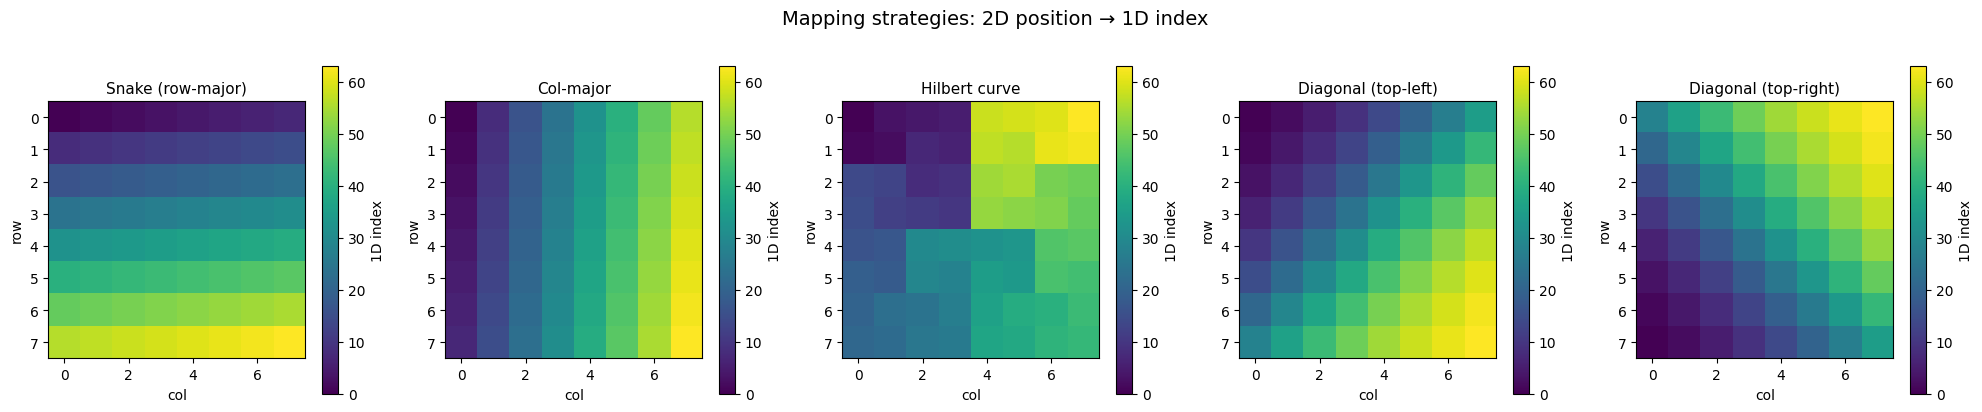

In [55]:
# visualize basic mappings on small grid
from hilbert import decode

def get_mapping_order(n, mapping):
    """Get the 1D index for each (row, col) position under a given mapping."""
    order = np.zeros((n, n), dtype=int)
    
    if mapping == 'snake':
        for row in range(n):
            for col in range(n):
                order[row, col] = row * n + col  # row-major
    
    elif mapping == 'colmajor':
        for row in range(n):
            for col in range(n):
                order[row, col] = col * n + row  # col-major
    
    elif mapping == 'hilbert':
        bits = int(np.log2(n))
        indices = np.arange(n * n, dtype=np.uint64)
        coords = decode(indices, 2, bits)
        for idx, (x, y) in enumerate(coords):
            order[y, x] = idx  # hilbert gives (x,y), we want (row,col)
    
    elif mapping == 'diagonal_tl':
        coords = _diagonal_indices_topleft(n)
        for idx, (x, y) in enumerate(coords):
            order[y, x] = idx
    
    elif mapping == 'diagonal_tr':
        coords = _diagonal_indices_topright(n)
        for idx, (x, y) in enumerate(coords):
            order[y, x] = idx
    
    return order

# visualize on 8x8 grid
n_vis = 8
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

basic_mappings = ['snake', 'colmajor', 'hilbert', 'diagonal_tl', 'diagonal_tr']
titles = ['Snake (row-major)', 'Col-major', 'Hilbert curve', 'Diagonal (top-left)', 'Diagonal (top-right)']

for ax, mapping, title in zip(axes, basic_mappings, titles):
    order = get_mapping_order(n_vis, mapping)
    im = ax.imshow(order, cmap='viridis')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('col')
    ax.set_ylabel('row')
    plt.colorbar(im, ax=ax, label='1D index')

plt.suptitle('Mapping strategies: 2D position → 1D index', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

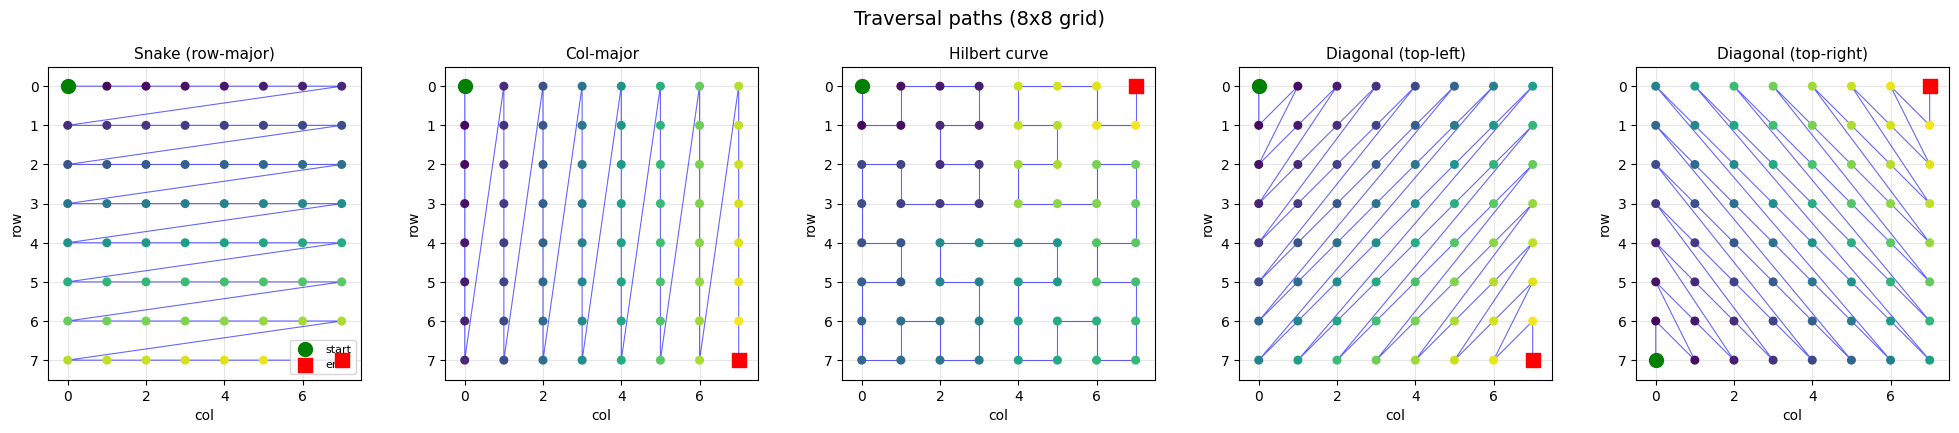

In [57]:
# show traversal path for each mapping
def plot_traversal_path(ax, n, mapping, title):
    """Draw lines showing the order of traversal."""
    order = get_mapping_order(n, mapping)
    
    # create inverse: 1D index -> (row, col)
    path = np.zeros((n*n, 2), dtype=int)
    for row in range(n):
        for col in range(n):
            idx = order[row, col]
            path[idx] = [row, col]
    
    # draw path (col on x-axis, row on y-axis, but invert y so 0 is at top)
    ax.plot(path[:, 1], path[:, 0], 'b-', alpha=0.6, linewidth=0.8)
    ax.scatter(path[:, 1], path[:, 0], c=np.arange(n*n), cmap='viridis', s=30, zorder=5)
    ax.scatter(path[0, 1], path[0, 0], c='green', s=100, marker='o', zorder=10, label='start')
    ax.scatter(path[-1, 1], path[-1, 0], c='red', s=100, marker='s', zorder=10, label='end')
    
    ax.set_xlim(-0.5, n-0.5)
    ax.set_ylim(n-0.5, -0.5)  # invert y-axis so row 0 is at top
    ax.set_aspect('equal')
    ax.set_xlabel('col')
    ax.set_ylabel('row')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

n_path = 8
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, mapping, title in zip(axes, basic_mappings, titles):
    plot_traversal_path(ax, n_path, mapping, title)

axes[0].legend(loc='lower right', fontsize=8)
plt.suptitle(f'Traversal paths ({n_path}x{n_path} grid)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Compression comparison across mappings

In [40]:
# compression comparison table
chi_values = [4, 8, 16, 32, 64, 128]

results = []
for Re, f_t in all_data:
    rho_orig, u_orig = compute_moments(D2Q9, f_t)
    
    for mapping in mappings:
        for chi in chi_values:
            mps_list, meta = compress_populations(f_t, max_bond=chi, mapping=mapping)
            f_recon = decompress_populations(mps_list, meta)
            rho_comp, u_comp = compute_moments(D2Q9, f_recon)
            
            f_err = np.linalg.norm(f_t - f_recon) / np.linalg.norm(f_t)
            u_err = np.linalg.norm(u_orig - u_comp) / np.linalg.norm(u_orig)
            
            if isinstance(meta, list):
                mps_bytes = sum(sum(t.data.nbytes for t in mps) for mps in mps_list)
            else:
                mps_bytes = sum(sum(t.data.nbytes for t in mps) for mps in mps_list)
            ratio = f_t.nbytes / mps_bytes
            
            results.append({
                'Re': Re, 'mapping': mapping, 'chi': chi,
                'f_err': f_err, 'u_err': u_err, 'ratio': ratio
            })

# show chi=16 comparison
print("Compression error at chi=16:")
print(f"{'Re':>6} {'snake':>12} {'hilbert':>12} {'perpop':>12}  {'winner':>8}")
print("-" * 55)
for Re in Re_values:
    errs = {}
    for m in mappings:
        r = next(r for r in results if r['Re']==Re and r['mapping']==m and r['chi']==16)
        errs[m] = r['f_err']
    winner = min(errs, key=errs.get)
    print(f"{Re:>6} {errs['snake']:>12.2e} {errs['hilbert']:>12.2e} {errs['perpop']:>12.2e}  {winner:>8}")

Compression error at chi=16:
    Re        snake      hilbert       perpop    winner
-------------------------------------------------------
   100     2.64e-05     3.07e-04     4.27e-03     snake
  1000     1.24e-04     6.33e-04     5.26e-03     snake
  5000     1.66e-03     3.50e-03     7.49e-03     snake


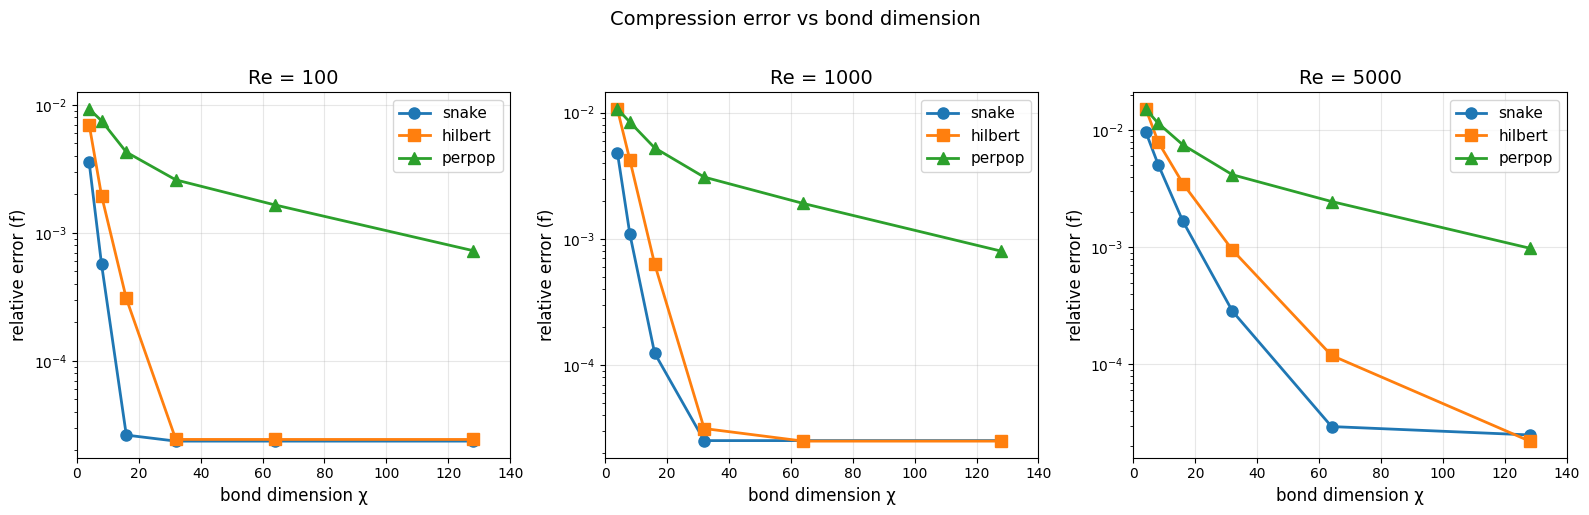

In [41]:
# plot: error vs chi for all 3 mappings, per Re
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'snake': 'C0', 'hilbert': 'C1', 'perpop': 'C2'}
markers = {'snake': 'o', 'hilbert': 's', 'perpop': '^'}

for ax, Re in zip(axes, Re_values):
    for mapping in mappings:
        data = [r for r in results if r['Re'] == Re and r['mapping'] == mapping]
        chis = [r['chi'] for r in data]
        errs = [r['f_err'] for r in data]
        ax.semilogy(chis, errs, f'{markers[mapping]}-', 
                   color=colors[mapping], label=mapping, linewidth=2, markersize=8)
    
    ax.set_xlabel('bond dimension χ', fontsize=12)
    ax.set_ylabel('relative error (f)', fontsize=12)
    ax.set_title(f'Re = {Re}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 140])

plt.suptitle('Compression error vs bond dimension', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Natural bond dimensions

In [42]:
# natural bond dimensions (no truncation) for each mapping
natural_bonds = {}

for Re, f_t in all_data:
    for mapping in mappings:
        mps_list, _ = compress_populations(f_t, max_bond=None, mapping=mapping)
        max_bond = max(mps.max_bond() for mps in mps_list)
        mean_bond = np.mean([mps.max_bond() for mps in mps_list])
        natural_bonds[(Re, mapping)] = {'max': max_bond, 'mean': mean_bond}

print("Natural bond dimensions (no truncation):")
print(f"{'Re':>6} {'mapping':>8} {'max_chi':>8} {'mean_chi':>9}")
print("-" * 35)
for Re in Re_values:
    for mapping in mappings:
        v = natural_bonds[(Re, mapping)]
        print(f"{Re:>6} {mapping:>8} {v['max']:>8} {v['mean']:>9.1f}")

Natural bond dimensions (no truncation):
    Re  mapping  max_chi  mean_chi
-----------------------------------
   100    snake       21      18.4
   100  hilbert       34      30.3
   100   perpop      249     119.4
  1000    snake       32      28.7
  1000  hilbert       44      39.2
  1000   perpop      251     126.3
  5000    snake       87      79.2
  5000  hilbert      117     109.7
  5000   perpop      253     152.2


In [43]:
# per-population bond dimensions for Re=1000
f_t = f_1000
print("Per-population natural bond dimensions (Re=1000):")
print(f"{'Pop':>4} {'Dir':>6} {'snake':>6} {'hilbert':>8} {'perpop':>8}")
print("-" * 38)

for i in range(9):
    bonds = {}
    for mapping in mappings:
        if mapping == 'perpop':
            pop_mapping = D2Q9_POP_MAPPINGS[i]
        else:
            pop_mapping = mapping
        mps, _ = field_to_qtt(f_t[i], max_bond=None, mapping=pop_mapping)
        bonds[mapping] = mps.max_bond()
    
    dir_name = velocity_names[i]
    print(f"{i:>4} {dir_name:>6} {bonds['snake']:>6} {bonds['hilbert']:>8} {bonds['perpop']:>8}")

Per-population natural bond dimensions (Re=1000):
 Pop    Dir  snake  hilbert   perpop
--------------------------------------
   0   Rest     19       28       19
   1   East     28       38       28
   2  North     28       40       32
   3   West     28       38       28
   4  South     29       40       31
   5     NE     31       42      250
   6     NW     32       42      249
   7     SW     31       44      251
   8     SE     32       41      249


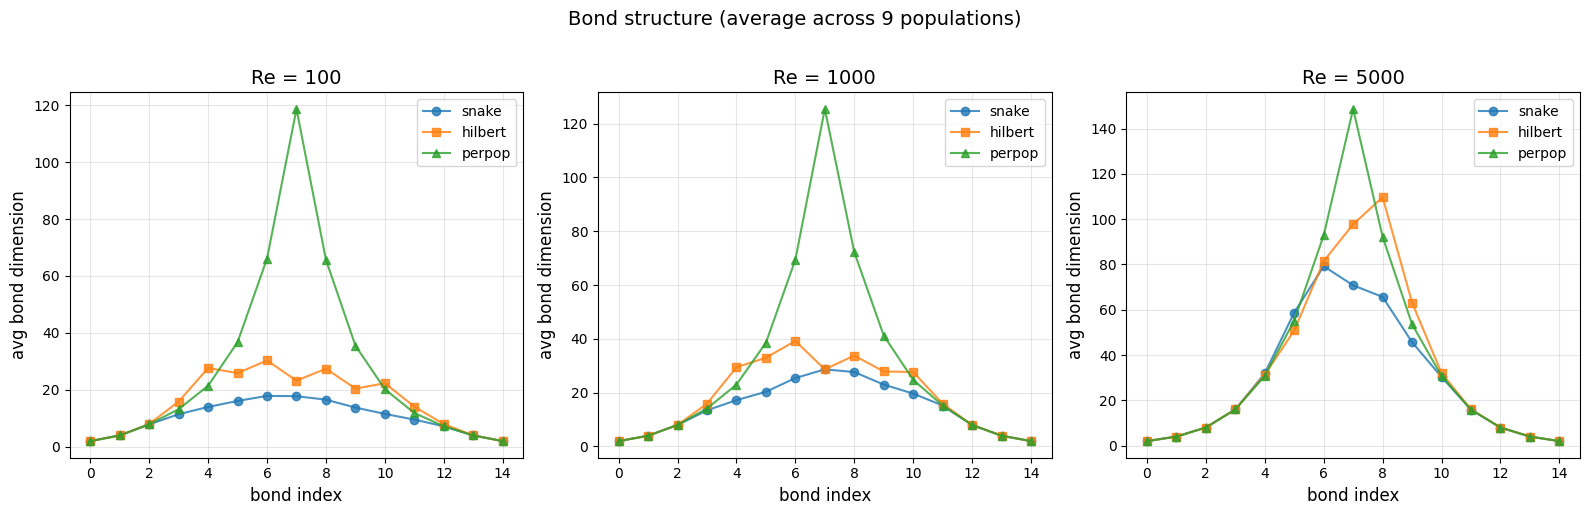

In [44]:
# bond structure visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (Re, f_t) in zip(axes, all_data):
    for mapping in mappings:
        mps_list, meta = compress_populations(f_t, max_bond=None, mapping=mapping)
        # average bond dims across populations
        L = 16  # log2(65536)
        avg_bonds = np.zeros(L-1)
        for mps in mps_list:
            bonds = [mps.bond_size(j, j+1) for j in range(L-1)]
            avg_bonds += np.array(bonds)
        avg_bonds /= 9
        
        ax.plot(range(L-1), avg_bonds, f'{markers[mapping]}-', 
               color=colors[mapping], label=mapping, alpha=0.8)
    
    ax.set_xlabel('bond index', fontsize=12)
    ax.set_ylabel('avg bond dimension', fontsize=12)
    ax.set_title(f'Re = {Re}', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Bond structure (average across 9 populations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Scaling analysis

In [45]:
# find minimum chi for target accuracy
target_u_err = 0.01
chi_test_values = [2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 128]

chi_required = {}
for Re, f_t in all_data:
    rho_orig, u_orig = compute_moments(D2Q9, f_t)
    
    for mapping in mappings:
        for chi in chi_test_values:
            mps_list, meta = compress_populations(f_t, max_bond=chi, mapping=mapping)
            f_recon = decompress_populations(mps_list, meta)
            _, u_comp = compute_moments(D2Q9, f_recon)
            u_err = np.linalg.norm(u_orig - u_comp) / np.linalg.norm(u_orig)
            
            if u_err < target_u_err:
                chi_required[(Re, mapping)] = chi
                break
        else:
            chi_required[(Re, mapping)] = chi_test_values[-1]

print(f"Minimum chi required for u_err < {target_u_err*100:.0f}%:")
print(f"{'Re':>6} {'snake':>8} {'hilbert':>10} {'perpop':>10}")
print("-" * 38)
for Re in Re_values:
    s = chi_required.get((Re, 'snake'), 'N/A')
    h = chi_required.get((Re, 'hilbert'), 'N/A')
    p = chi_required.get((Re, 'perpop'), 'N/A')
    print(f"{Re:>6} {s:>8} {h:>10} {p:>10}")

Minimum chi required for u_err < 1%:
    Re    snake    hilbert     perpop
--------------------------------------
   100       12         16        128
  1000       12         24        128
  5000       32         48        128


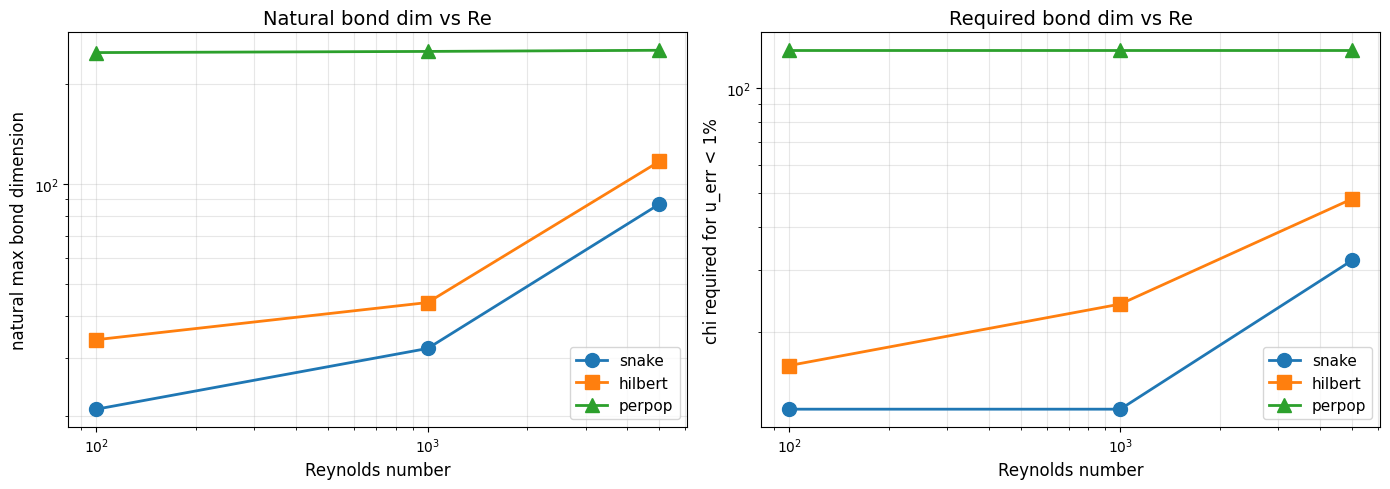


Power law fits: chi ~ a * Re^alpha
  snake    (natural):  chi ~ 3.73 * Re^0.351
  hilbert  (natural):  chi ~ 7.45 * Re^0.302
  perpop   (natural):  chi ~ 244.33 * Re^0.004

  snake    (required): chi ~ 3.50 * Re^0.233
  hilbert  (required): chi ~ 4.25 * Re^0.274
  perpop   (required): chi ~ 128.00 * Re^0.000


In [46]:
# scaling plots: log-log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: natural bond dimension vs Re
ax = axes[0]
for mapping in mappings:
    res = [(Re, natural_bonds[(Re, mapping)]['max']) for Re in Re_values]
    res_arr = np.array(res)
    ax.loglog(res_arr[:, 0], res_arr[:, 1], f'{markers[mapping]}-', 
             color=colors[mapping], label=mapping, linewidth=2, markersize=10)

ax.set_xlabel('Reynolds number', fontsize=12)
ax.set_ylabel('natural max bond dimension', fontsize=12)
ax.set_title('Natural bond dim vs Re', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

# Right: required chi for target accuracy
ax = axes[1]
for mapping in mappings:
    res = [(Re, chi_required[(Re, mapping)]) for Re in Re_values]
    res_arr = np.array(res)
    ax.loglog(res_arr[:, 0], res_arr[:, 1], f'{markers[mapping]}-', 
             color=colors[mapping], label=mapping, linewidth=2, markersize=10)

ax.set_xlabel('Reynolds number', fontsize=12)
ax.set_ylabel(f'chi required for u_err < {target_u_err*100:.0f}%', fontsize=12)
ax.set_title('Required bond dim vs Re', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# power law fits
print("\nPower law fits: chi ~ a * Re^alpha")
Re_arr = np.array(Re_values)
log_Re = np.log(Re_arr)

for mapping in mappings:
    chi_nat = np.array([natural_bonds[(Re, mapping)]['max'] for Re in Re_values])
    alpha, log_a = np.polyfit(log_Re, np.log(chi_nat), 1)
    print(f"  {mapping:8s} (natural):  chi ~ {np.exp(log_a):.2f} * Re^{alpha:.3f}")

print()
for mapping in mappings:
    chi_req = np.array([chi_required[(Re, mapping)] for Re in Re_values])
    alpha, log_a = np.polyfit(log_Re, np.log(chi_req), 1)
    print(f"  {mapping:8s} (required): chi ~ {np.exp(log_a):.2f} * Re^{alpha:.3f}")

## 6. Spatial error distribution

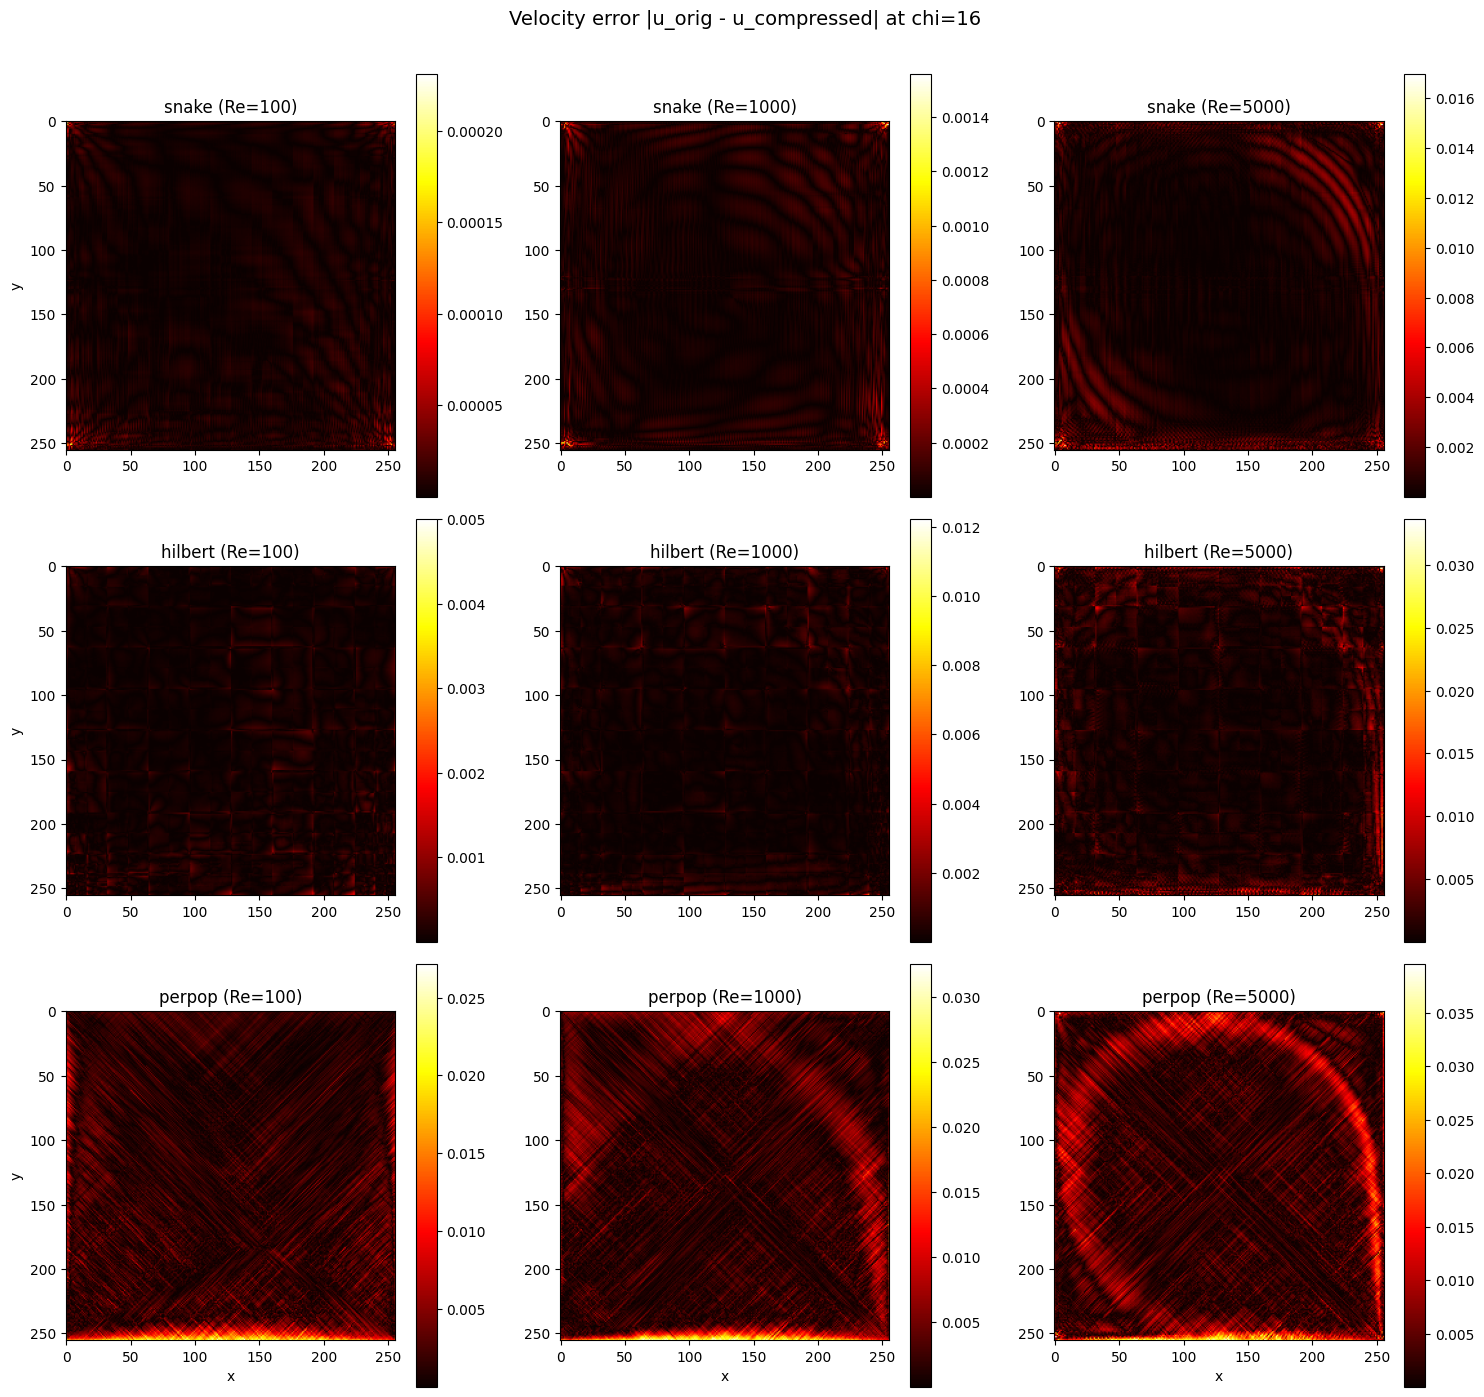

In [47]:
# spatial error distribution at chi=16
chi_fixed = 16

fig, axes = plt.subplots(3, 3, figsize=(15, 14))

for col, (Re, f_t) in enumerate(all_data):
    rho_orig, u_orig = compute_moments(D2Q9, f_t)
    speed_orig = np.sqrt(u_orig[0]**2 + u_orig[1]**2)
    
    for row, mapping in enumerate(mappings):
        mps_list, meta = compress_populations(f_t, max_bond=chi_fixed, mapping=mapping)
        f_recon = decompress_populations(mps_list, meta)
        _, u_comp = compute_moments(D2Q9, f_recon)
        speed_comp = np.sqrt(u_comp[0]**2 + u_comp[1]**2)
        err = np.abs(speed_orig - speed_comp)
        
        ax = axes[row, col]
        im = ax.imshow(err.T, cmap='hot')
        ax.set_title(f'{mapping} (Re={Re})')
        plt.colorbar(im, ax=ax)
        
        if row == 2:
            ax.set_xlabel('x')
        if col == 0:
            ax.set_ylabel('y')

plt.suptitle(f'Velocity error |u_orig - u_compressed| at chi={chi_fixed}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

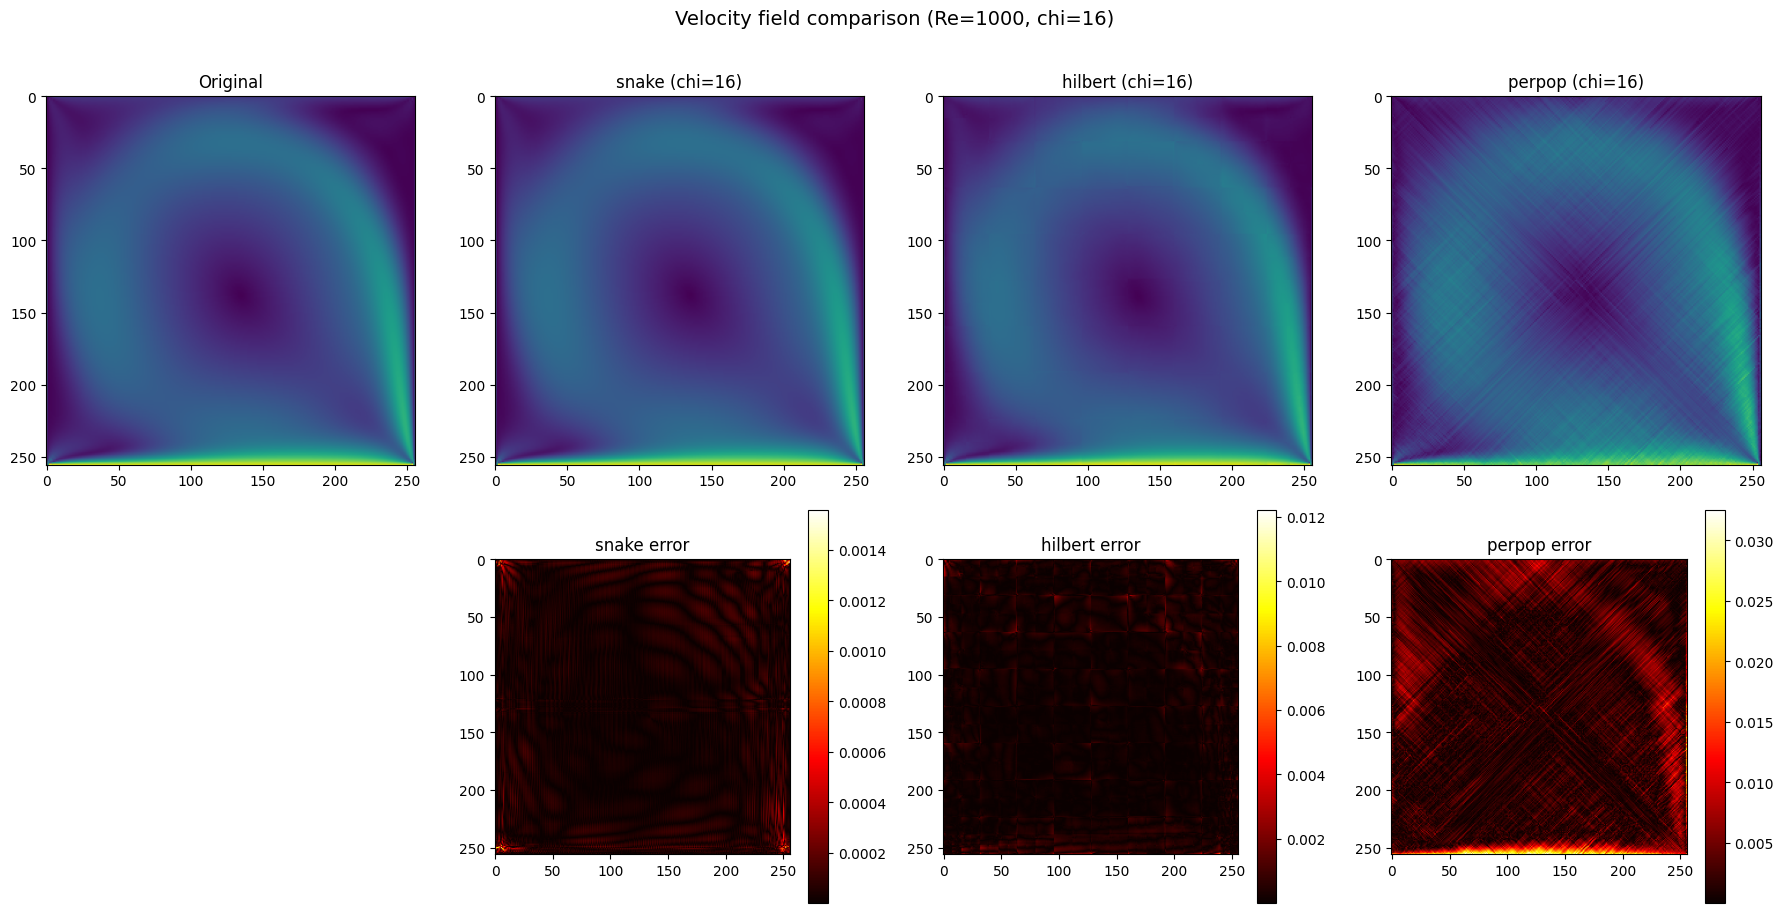

In [48]:
# velocity field comparison at chi=16 for Re=1000
Re_show = 1000
f_show = f_1000
chi_show = 16

rho_orig, u_orig = compute_moments(D2Q9, f_show)
speed_orig = np.sqrt(u_orig[0]**2 + u_orig[1]**2)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# top row: velocity fields
axes[0, 0].imshow(speed_orig.T, cmap='viridis')
axes[0, 0].set_title('Original')

for i, mapping in enumerate(mappings):
    mps_list, meta = compress_populations(f_show, max_bond=chi_show, mapping=mapping)
    f_recon = decompress_populations(mps_list, meta)
    _, u_comp = compute_moments(D2Q9, f_recon)
    speed_comp = np.sqrt(u_comp[0]**2 + u_comp[1]**2)
    
    axes[0, i+1].imshow(speed_comp.T, cmap='viridis')
    axes[0, i+1].set_title(f'{mapping} (chi={chi_show})')
    
    # bottom row: errors
    err = np.abs(speed_orig - speed_comp)
    im = axes[1, i+1].imshow(err.T, cmap='hot')
    axes[1, i+1].set_title(f'{mapping} error')
    plt.colorbar(im, ax=axes[1, i+1])

axes[1, 0].axis('off')

plt.suptitle(f'Velocity field comparison (Re={Re_show}, chi={chi_show})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Why diagonal mappings fail: 1D signal analysis

QTT compression works by reshaping the 1D array into a tensor of shape (2,2,...,2) and decomposing it. 
**Smooth/structured 1D signals compress well, chaotic signals don't.**

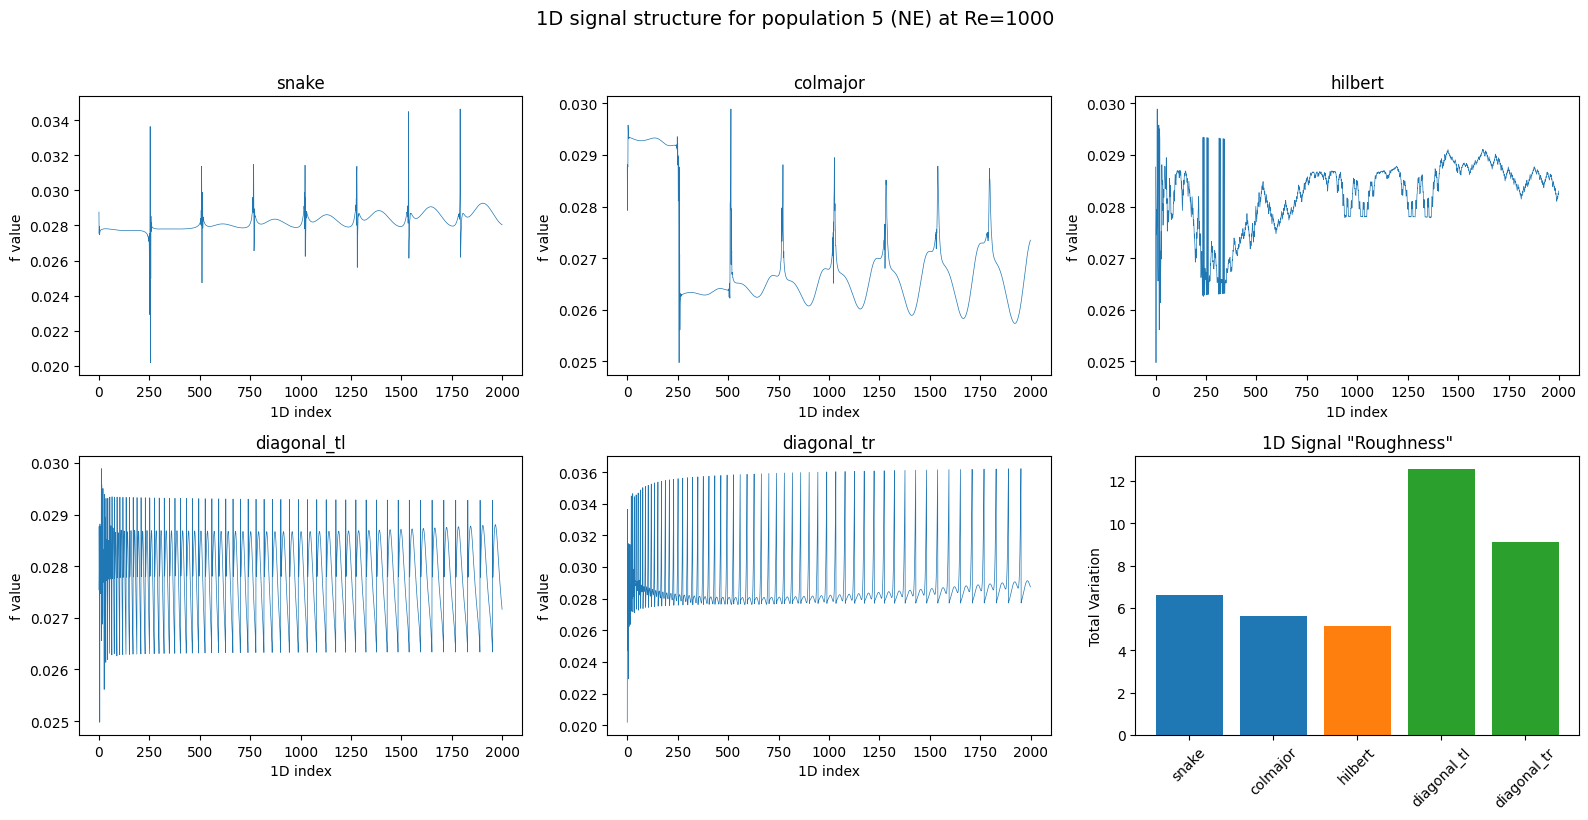

Signal smoothness metrics (lower = smoother = better for QTT):
Mapping      Total Variation  Gradient L2
------------------------------------------
snake                   6.63         0.13
colmajor                5.62         0.10
hilbert                 5.15         0.08
diagonal_tl            12.55         0.22
diagonal_tr             9.10         0.19


In [69]:
# Compare 1D signal structure for different mappings
from tn.mapping import flatten_2d

# Use population 5 (NE diagonal) from Re=1000 as test case
pop_idx = 5
field_2d = f_1000[pop_idx]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

all_mappings = ['snake', 'colmajor', 'hilbert', 'diagonal_tl', 'diagonal_tr']

# Top row: 1D signals (first 2000 points to see structure)
for i, mapping in enumerate(all_mappings[:3]):
    flat, _ = flatten_2d(field_2d, mapping=mapping)
    axes[0, i].plot(flat[:2000], linewidth=0.5)
    axes[0, i].set_title(f'{mapping}')
    axes[0, i].set_xlabel('1D index')
    axes[0, i].set_ylabel('f value')

# Bottom row: remaining mappings + smoothness metric
for i, mapping in enumerate(all_mappings[3:]):
    flat, _ = flatten_2d(field_2d, mapping=mapping)
    axes[1, i].plot(flat[:2000], linewidth=0.5)
    axes[1, i].set_title(f'{mapping}')
    axes[1, i].set_xlabel('1D index')
    axes[1, i].set_ylabel('f value')

# Compute smoothness metrics for all mappings
ax = axes[1, 2]
metrics = {}
for mapping in all_mappings:
    flat, _ = flatten_2d(field_2d, mapping=mapping)
    # Total variation: sum of absolute differences between consecutive points
    tv = np.sum(np.abs(np.diff(flat)))
    # Gradient magnitude (L2)
    grad_l2 = np.linalg.norm(np.diff(flat))
    metrics[mapping] = {'TV': tv, 'grad_L2': grad_l2}

# Bar plot of total variation
names = list(metrics.keys())
tvs = [metrics[m]['TV'] for m in names]
colors_bar = ['C0', 'C0', 'C1', 'C2', 'C2']
bars = ax.bar(names, tvs, color=colors_bar)
ax.set_ylabel('Total Variation')
ax.set_title('1D Signal "Roughness"')
ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'1D signal structure for population {pop_idx} ({velocity_names[pop_idx]}) at Re=1000', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print metrics
print("Signal smoothness metrics (lower = smoother = better for QTT):")
print(f"{'Mapping':<12} {'Total Variation':>15} {'Gradient L2':>12}")
print("-" * 42)
for m in all_mappings:
    print(f"{m:<12} {metrics[m]['TV']:>15.2f} {metrics[m]['grad_L2']:>12.2f}")

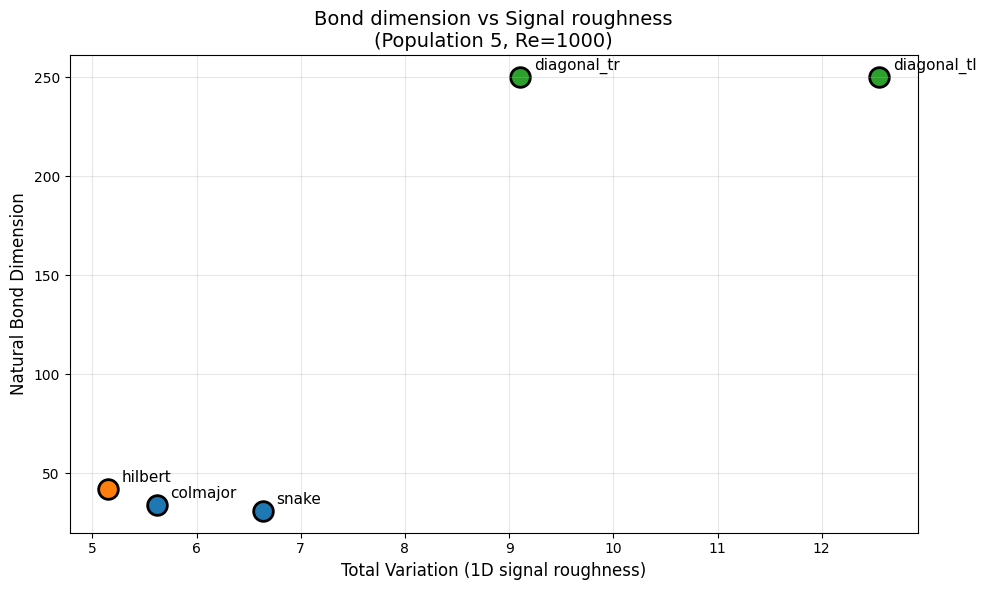

Correlation between signal roughness and bond dimension:
  Pearson r = 0.894


In [53]:
# Final comparison: natural bond dim vs signal roughness
fig, ax = plt.subplots(figsize=(10, 6))

# Get natural bond dims and total variation for each mapping on pop 5
all_mappings_test = ['snake', 'colmajor', 'hilbert', 'diagonal_tl', 'diagonal_tr']
bond_dims = []
total_vars = []

for mapping in all_mappings_test:
    # Natural bond dim
    mps, _ = field_to_qtt(f_1000[5], max_bond=None, mapping=mapping)
    bond_dims.append(mps.max_bond())
    
    # Total variation
    flat, _ = flatten_2d(f_1000[5], mapping=mapping)
    tv = np.sum(np.abs(np.diff(flat)))
    total_vars.append(tv)

# Scatter plot
colors_scatter = ['C0', 'C0', 'C1', 'C2', 'C2']
for i, mapping in enumerate(all_mappings_test):
    ax.scatter(total_vars[i], bond_dims[i], s=200, c=colors_scatter[i], 
               label=mapping, edgecolors='black', linewidth=2)
    ax.annotate(mapping, (total_vars[i], bond_dims[i]), 
                textcoords="offset points", xytext=(10, 5), fontsize=11)

ax.set_xlabel('Total Variation (1D signal roughness)', fontsize=12)
ax.set_ylabel('Natural Bond Dimension', fontsize=12)
ax.set_title('Bond dimension vs Signal roughness\n(Population 5, Re=1000)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Correlation between signal roughness and bond dimension:")
print(f"  Pearson r = {np.corrcoef(total_vars, bond_dims)[0,1]:.3f}")

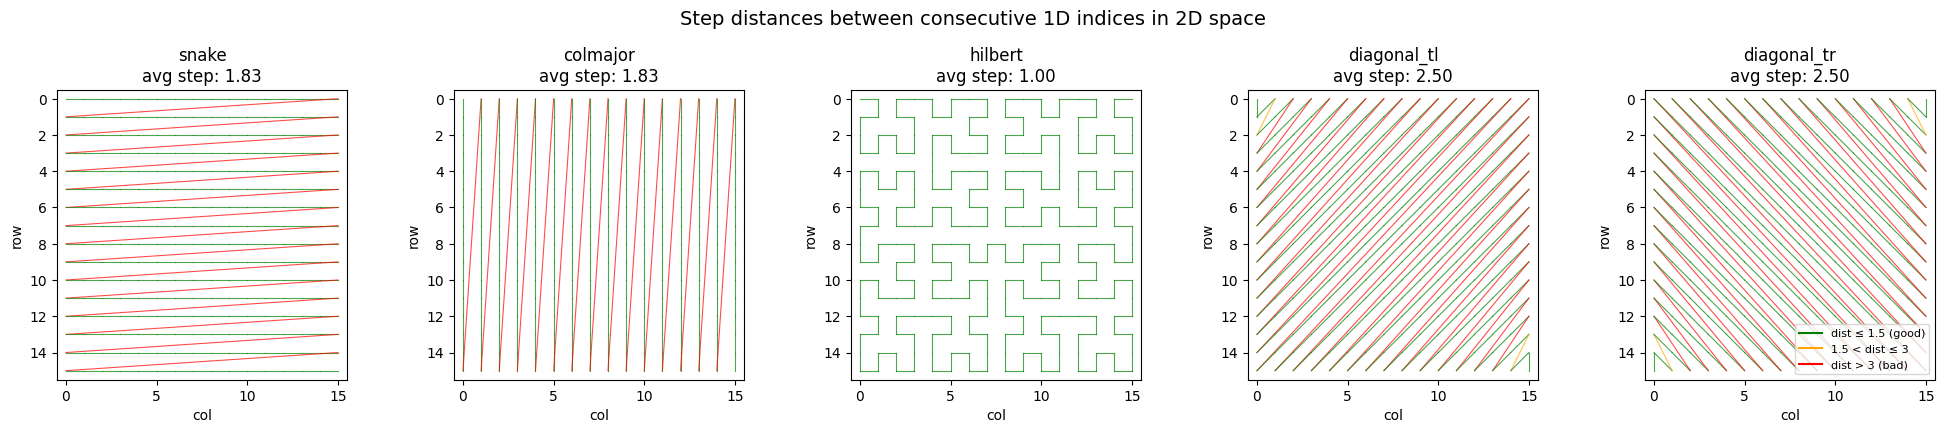

Average 2D distance between consecutive 1D indices:
  snake       : mean=1.83, max=15.0
  colmajor    : mean=1.83, max=15.0
  hilbert     : mean=1.00, max=1.0
  diagonal_tl : mean=2.50, max=20.5
  diagonal_tr : mean=2.50, max=20.5


In [54]:
# Visualize the "jumps" in 1D index space
# For each mapping, show where consecutive 1D indices land in 2D space

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

n_small = 16  # small grid for visualization

for ax, mapping in zip(axes, all_mappings):
    order = get_mapping_order(n_small, mapping)
    
    # For each pair of consecutive 1D indices, compute the 2D distance
    path = np.zeros((n_small*n_small, 2), dtype=int)
    for row in range(n_small):
        for col in range(n_small):
            idx = order[row, col]
            path[idx] = [row, col]
    
    # Compute step distances
    steps = np.diff(path, axis=0)
    distances = np.sqrt(steps[:, 0]**2 + steps[:, 1]**2)
    
    # Draw lines colored by distance (col on x, row on y, inverted)
    for i in range(len(path)-1):
        r0, c0 = path[i]
        r1, c1 = path[i+1]
        dist = distances[i]
        color = 'green' if dist <= 1.5 else ('orange' if dist <= 3 else 'red')
        ax.plot([c0, c1], [r0, r1], color=color, linewidth=0.8, alpha=0.7)
    
    ax.set_title(f'{mapping}\navg step: {np.mean(distances):.2f}')
    ax.set_xlim(-0.5, n_small-0.5)
    ax.set_ylim(n_small-0.5, -0.5)  # invert y so row 0 at top
    ax.set_aspect('equal')
    ax.set_xlabel('col')
    ax.set_ylabel('row')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', label='dist ≤ 1.5 (good)'),
    Line2D([0], [0], color='orange', label='1.5 < dist ≤ 3'),
    Line2D([0], [0], color='red', label='dist > 3 (bad)')
]
axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle('Step distances between consecutive 1D indices in 2D space', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print average step distances
print("Average 2D distance between consecutive 1D indices:")
for mapping in all_mappings:
    order = get_mapping_order(n_small, mapping)
    path = np.zeros((n_small*n_small, 2), dtype=int)
    for row in range(n_small):
        for col in range(n_small):
            path[order[row, col]] = [row, col]
    distances = np.sqrt(np.sum(np.diff(path, axis=0)**2, axis=1))
    print(f"  {mapping:<12}: mean={np.mean(distances):.2f}, max={np.max(distances):.1f}")